# Breast Cancer Diagnosis Prediction: Supervised Classification & KMeans Clustering

**Dataset:** `bdata.csv` (569 records; 21 numeric diagnostic features)  
**Target variable:** `diagnosis` (0 = benign, 1 = malignant)

Name: Dixin Zhang


### 1 Import necessary libraries


In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling / metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Plot styling (clean + consistent)
def prettify(ax):
    """Lightweight styling for matplotlib axes."""
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Global defaults (feel free to tweak)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

### 1.2 Load dataset and initial EDA


In [3]:
DATA_PATH = "bdata.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

df.info()

Shape: (569, 23)


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      569 non-null    int64  
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
 11  radius_se               569 non-null    float64
 12  texture_se              569 non-null    float64
 13  perimeter_se            569 non-null    float64
 14  area_se                 569 non-null    fl

In [4]:
# Basic data quality checks
print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nNumber of duplicated rows:", df.duplicated().sum())



Missing values per column:


id                        0
radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean          0
concavity_mean            0
concave points_mean       0
symmetry_mean             0
fractal_dimension_mean    0
radius_se                 0
texture_se                0
perimeter_se              0
area_se                   0
smoothness_se             0
compactness_se            0
concavity_se              0
concave points_se         0
symmetry_se               0
fractal_dimension_se      0
radius_worst              0
diagnosis                 0
dtype: int64


Number of duplicated rows: 0


In [5]:
# Target distribution
TARGET = "diagnosis"

print("\nTarget value counts:")
display(df[TARGET].value_counts())

print("\nTarget proportions:")
display(df[TARGET].value_counts(normalize=True).rename("proportion"))



Target value counts:


diagnosis
0    357
1    212
Name: count, dtype: int64


Target proportions:


diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64

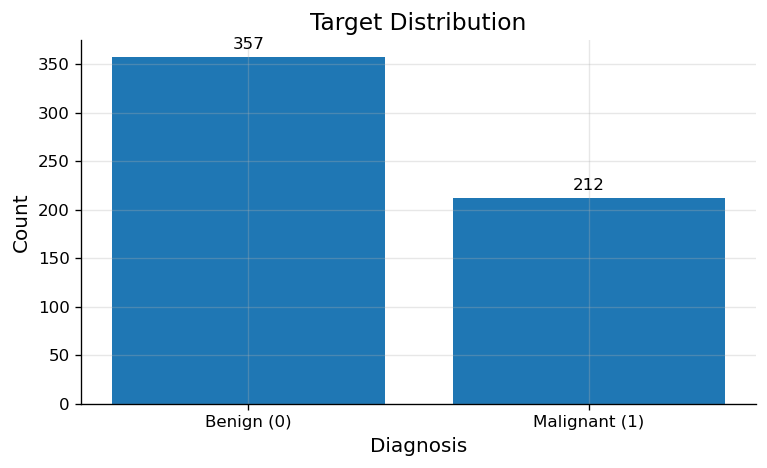

In [6]:
# Quick visualization: target distribution (prettier)
counts = df[TARGET].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(counts.index.astype(str), counts.values)

ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.set_title("Target Distribution")
ax.set_xticks(range(len(counts)))
# If your labels are 0/1, show a friendly name; otherwise fall back to the raw value
if set(counts.index.tolist()) == {0, 1}:
    ax.set_xticklabels(["Benign (0)", "Malignant (1)"], rotation=0)
else:
    ax.set_xticklabels([str(x) for x in counts.index], rotation=0)

ax.bar_label(bars, padding=3, fontsize=10)
prettify(ax)
fig.tight_layout()
plt.show()

In [7]:
# Quick numeric summary
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


### 1.3 Data preprocessing

Key steps:
- Drop non-predictive identifier columns (e.g., `id`).
- Separate predictors `X` and target `y`.
- Apply scaling in pipelines for models sensitive to feature magnitude.


In [8]:
# Drop non-predictive column(s)
DROP_COLS = ["id"]
X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass balance (y=1 rate):", round(y.mean(), 4))
display(X.head())


X shape: (569, 21)
y shape: (569,)

Class balance (y=1 rate): 0.3726


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54


### 1.4 Train/test split

We use a **stratified** split to preserve the benign/malignant class ratio in both sets.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train y distribution:\n", y_train.value_counts(normalize=True))
print("Test  y distribution:\n", y_test.value_counts(normalize=True))


Train shape: (455, 21) | Test shape: (114, 21)
Train y distribution:
 diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Test  y distribution:
 diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 2. Explaining Metrics

- **Recall (Sensitivity):** ability to catch malignant cases (reduces false negatives).
- **Precision:** how reliable malignant predictions are (reduces unnecessary follow-ups).
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** threshold-independent discrimination ability.


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

POS_LABEL = 1  # 1 = malignant

def get_scores(y_true, y_pred, y_score=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
    }
    if y_score is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        out["roc_auc"] = np.nan
    return out

def get_positive_score(model, X_data):
    """
    For ROC/AUC:
    - use predict_proba[:,1] if available
    - otherwise use decision_function
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return None

def fit_and_evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_score = get_positive_score(model, X_te)

    scores = get_scores(y_te, y_pred, y_score)
    scores["model"] = name
    return model, scores


## 3. Supervised Learning: Classification Models (Baseline)

Training four classification models using Scikit-Learn:
1. Logistic Regression  
2. Decision Tree  
3. Naive Bayes  
4. Neural Network (MLP)

For scale-sensitive models, we use a **Pipeline** with `StandardScaler` to avoid data leakage.


In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ]),
    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(50, 50),
            activation="relu",
            solver="adam",
            max_iter=2000,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

list(models.keys())


['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'Neural Network (MLP)']

In [12]:
fitted_models = {}
results = []

for name, model in models.items():
    fitted, score_dict = fit_and_evaluate(model, X_train, y_train, X_test, y_test, name=name)
    fitted_models[name] = fitted
    results.append(score_dict)

results_df = pd.DataFrame(results).set_index("model").sort_values(by="roc_auc", ascending=False)
display(results_df)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.947368,0.950000,0.904762,0.926829,0.988426
Neural Network (MLP),0.921053,0.923077,0.857143,0.888889,0.982143
Naive Bayes,0.894737,0.894737,0.809524,0.850000,0.980159
Decision Tree,0.921053,0.902439,0.880952,0.891566,0.912698


### 3.1 Cross-validation (Stratified 5-fold)

Cross-validation provides a more stable estimate of performance than a single split.


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []

for name, model in models.items():
    cv_out = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for k in scoring.keys():
        row[f"{k}_mean"] = np.mean(cv_out[f"test_{k}"])
        row[f"{k}_std"] = np.std(cv_out[f"test_{k}"])
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("model").sort_values(by="roc_auc_mean", ascending=False)
display(cv_df)


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Logistic Regression,0.964835,0.004396,0.970053,0.018607,0.935294,0.011765,0.952139,0.005507,0.992054,0.005020
Naive Bayes,0.927473,0.022628,0.939541,0.041342,0.864706,0.071077,0.897983,0.032786,0.978947,0.008544
Neural Network (MLP),0.916484,0.026556,0.952930,0.025184,0.817647,0.072998,0.878027,0.045179,0.975129,0.011623
Decision Tree,0.923077,0.013900,0.896760,0.031121,0.900000,0.047788,0.897030,0.019943,0.918421,0.018466


### 3.2 Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)

Tuning selected models to improve generalization and compare tuned vs. baseline performance.


In [14]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# 1) Logistic Regression tuning
lr_pipe = models["Logistic Regression"]
lr_param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"]
}
lr_search = GridSearchCV(
    lr_pipe, lr_param_grid,
    scoring="roc_auc",
    cv=cv, n_jobs=-1
)
lr_search.fit(X_train, y_train)

# 2) Decision Tree tuning
dt_pipe = models["Decision Tree"]
dt_param_grid = {
    "clf__max_depth": [None, 3, 5, 7, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__class_weight": [None, "balanced"]
}
dt_search = GridSearchCV(
    dt_pipe, dt_param_grid,
    scoring="roc_auc",
    cv=cv, n_jobs=-1
)
dt_search.fit(X_train, y_train)

# 3) MLP tuning (random search to keep it lighter)
mlp_pipe = models["Neural Network (MLP)"]
mlp_param_dist = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
    "clf__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "clf__learning_rate_init": [1e-4, 1e-3, 1e-2]
}
mlp_search = RandomizedSearchCV(
    mlp_pipe, mlp_param_dist,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
mlp_search.fit(X_train, y_train)

print("Best LR CV ROC_AUC:", round(lr_search.best_score_, 4))
print("Best DT CV ROC_AUC:", round(dt_search.best_score_, 4))
print("Best MLP CV ROC_AUC:", round(mlp_search.best_score_, 4))


Best LR CV ROC_AUC: 0.9928
Best DT CV ROC_AUC: 0.9648
Best MLP CV ROC_AUC: 0.9882


In [15]:
tuned_models = {
    "Tuned Logistic Regression": lr_search.best_estimator_,
    "Tuned Decision Tree": dt_search.best_estimator_,
    "Tuned MLP": mlp_search.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    fitted, score_dict = fit_and_evaluate(model, X_train, y_train, X_test, y_test, name=name)
    tuned_models[name] = fitted
    tuned_results.append(score_dict)

tuned_df = pd.DataFrame(tuned_results).set_index("model").sort_values(by="roc_auc", ascending=False)
display(tuned_df)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Tuned Logistic Regression,0.964912,1.000000,0.904762,0.950000,0.987103
Tuned MLP,0.947368,0.973684,0.880952,0.925000,0.984127
Tuned Decision Tree,0.921053,0.883721,0.904762,0.894118,0.910053


### 3.3 Tuned model evaluation (test set)

Reporting confusion matrices, classification reports, and ROC curves for tuned models.


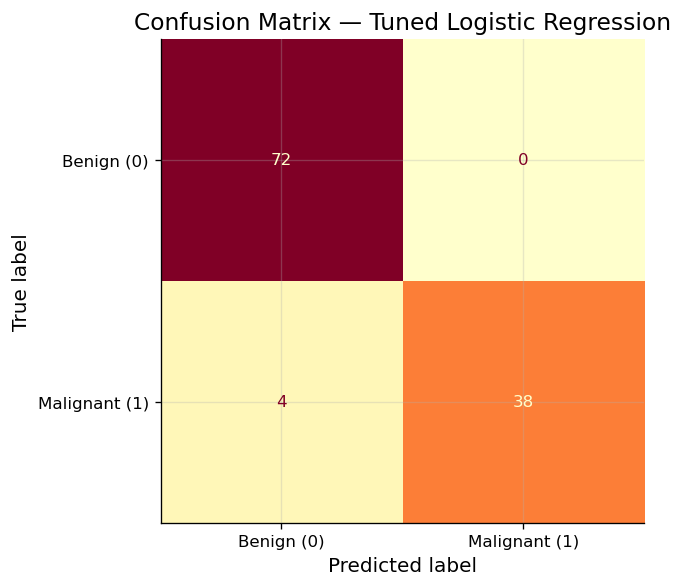


Classification Report — Tuned Logistic Regression
              precision    recall  f1-score   support

           0     0.9474    1.0000    0.9730        72
           1     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114



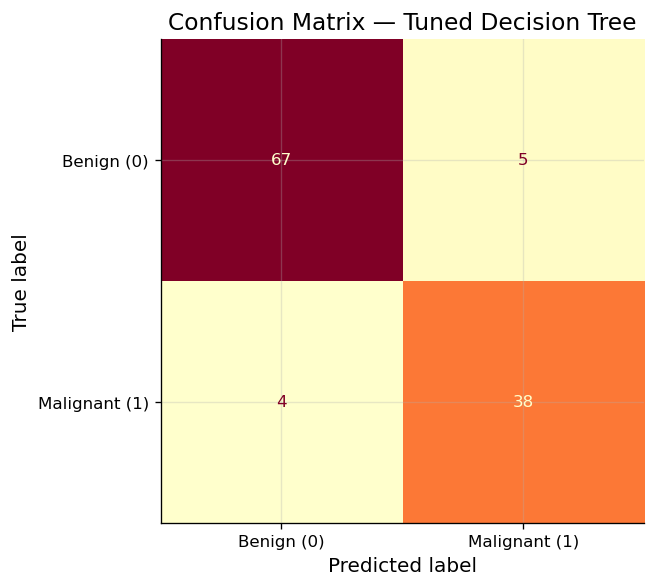


Classification Report — Tuned Decision Tree
              precision    recall  f1-score   support

           0     0.9437    0.9306    0.9371        72
           1     0.8837    0.9048    0.8941        42

    accuracy                         0.9211       114
   macro avg     0.9137    0.9177    0.9156       114
weighted avg     0.9216    0.9211    0.9212       114



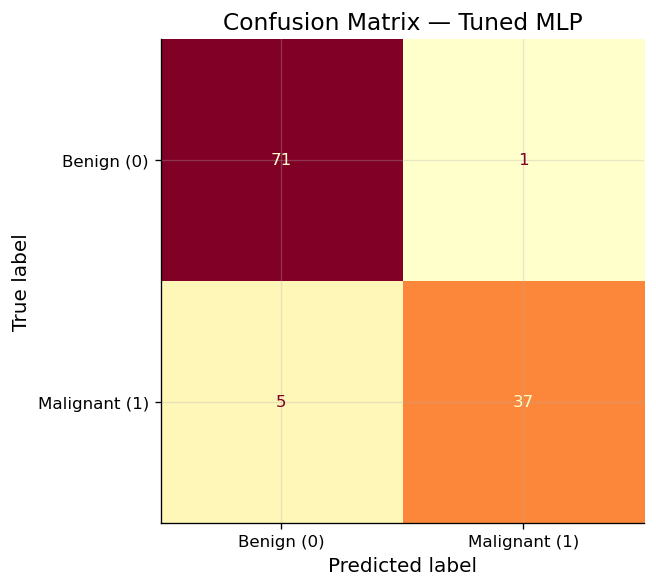


Classification Report — Tuned MLP
              precision    recall  f1-score   support

           0     0.9342    0.9861    0.9595        72
           1     0.9737    0.8810    0.9250        42

    accuracy                         0.9474       114
   macro avg     0.9539    0.9335    0.9422       114
weighted avg     0.9488    0.9474    0.9468       114



In [16]:
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Benign (0)", "Malignant (1)"],
        values_format="d",
        cmap="YlOrRd",  # try: "cividis", "YlGnBu", "Purples"
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_aspect("equal")
    prettify(ax)
    fig.tight_layout()
    plt.show()

    print(f"\nClassification Report — {name}")
    print(classification_report(y_test, y_pred, digits=4))

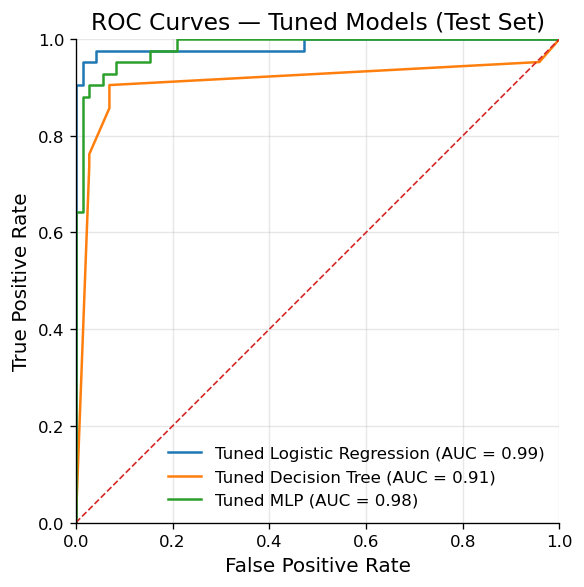

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("ROC Curves — Tuned Models (Test Set)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
prettify(ax)
fig.tight_layout()
plt.show()

### 3.4 Comparative analysis (baseline vs. tuned)


In [18]:
# Combine baseline + tuned metrics into one table
all_results_df = pd.concat([
    results_df.assign(type="baseline"),
    tuned_df.assign(type="tuned")
]).sort_values(by="roc_auc", ascending=False)

display(all_results_df)

# Create one model dictionary that includes baseline + tuned
all_models = {}
all_models.update(fitted_models)
all_models.update(tuned_models)

# Choose best model by ROC_AUC (you can change to recall/f1 if desired)
best_model_name = all_results_df.index[0]
best_model = all_models[best_model_name]

print("Best model (by ROC_AUC):", best_model_name)


,accuracy,precision,recall,f1,roc_auc,type
model,,,,,,
Logistic Regression,0.947368,0.950000,0.904762,0.926829,0.988426,baseline
Tuned Logistic Regression,0.964912,1.000000,0.904762,0.950000,0.987103,tuned
Tuned MLP,0.947368,0.973684,0.880952,0.925000,0.984127,tuned
Neural Network (MLP),0.921053,0.923077,0.857143,0.888889,0.982143,baseline
Naive Bayes,0.894737,0.894737,0.809524,0.850000,0.980159,baseline
Decision Tree,0.921053,0.902439,0.880952,0.891566,0.912698,baseline
Tuned Decision Tree,0.921053,0.883721,0.904762,0.894118,0.910053,tuned


Best model (by ROC_AUC): Logistic Regression


### 3.5 Model interpretability (feature importance)

,abs_coef
radius_worst,7.082146
concavity_mean,4.259240
texture_mean,2.066093
area_se,1.724162
compactness_mean,1.630098
fractal_dimension_se,1.491617
perimeter_mean,1.432414
concave points_mean,1.361938
radius_mean,1.306724
fractal_dimension_mean,1.090042


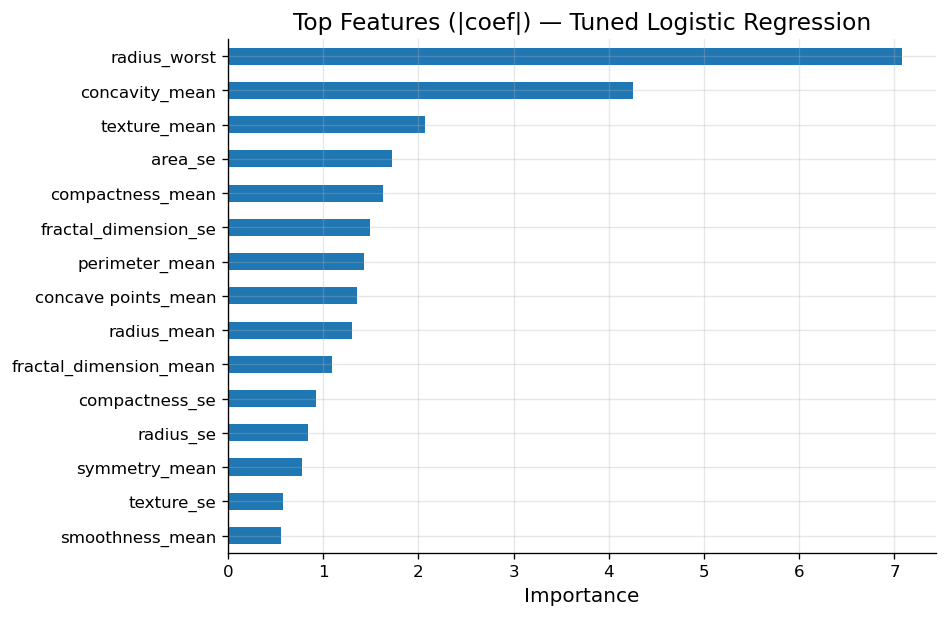

,importance
concave points_mean,0.774678
radius_worst,0.137258
texture_mean,0.043334
concavity_mean,0.029566
area_se,0.015165
smoothness_mean,0.000000
area_mean,0.000000
perimeter_mean,0.000000
radius_mean,0.000000
fractal_dimension_mean,0.000000


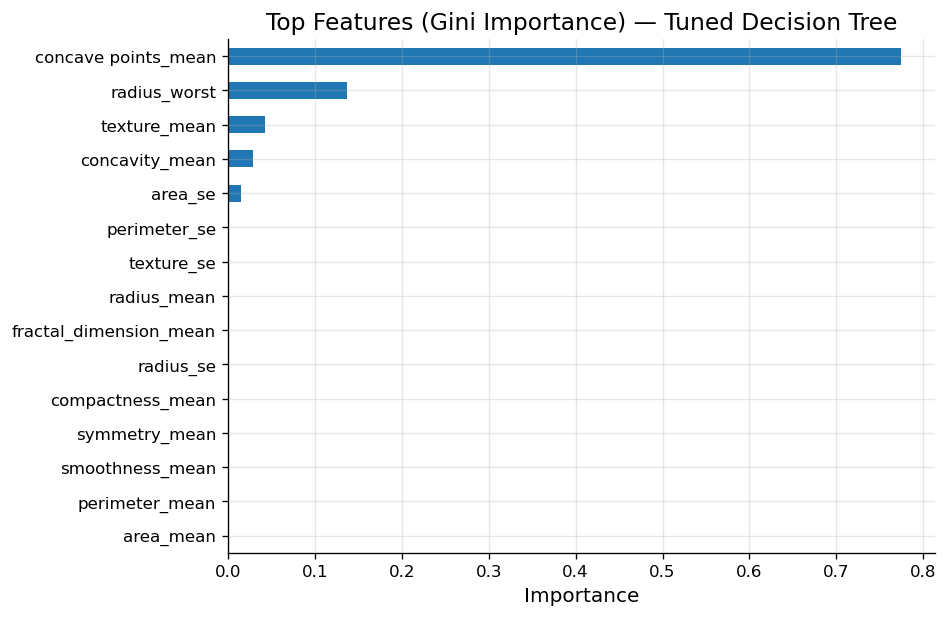

In [19]:
feature_names = X_train.columns

def show_top_features_from_pipeline(model, title, top_n=15):
    if not hasattr(model, "named_steps") or "clf" not in model.named_steps:
        print(f"[Skip] {title}: not a Pipeline with 'clf' step.")
        return

    clf = model.named_steps["clf"]

    if hasattr(clf, "coef_"):
        imp = pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False).head(top_n)
        display(imp.to_frame("abs_coef"))

        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * top_n)))
        imp.sort_values().plot(kind="barh", ax=ax)
        ax.set_title(f"Top Features (|coef|) — {title}")
        ax.set_xlabel("Importance")
        prettify(ax)
        fig.tight_layout()
        plt.show()

    elif hasattr(clf, "feature_importances_"):
        imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
        display(imp.to_frame("importance"))

        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * top_n)))
        imp.sort_values().plot(kind="barh", ax=ax)
        ax.set_title(f"Top Features (Gini Importance) — {title}")
        ax.set_xlabel("Importance")
        prettify(ax)
        fig.tight_layout()
        plt.show()
    else:
        print(f"[Skip] {title}: no coef_ or feature_importances_.")

# Try for tuned LR/DT (if they exist)
if "Tuned Logistic Regression" in tuned_models:
    show_top_features_from_pipeline(tuned_models["Tuned Logistic Regression"], "Tuned Logistic Regression")
if "Tuned Decision Tree" in tuned_models:
    show_top_features_from_pipeline(tuned_models["Tuned Decision Tree"], "Tuned Decision Tree")

,perm_importance_mean
radius_worst,0.047851
concavity_mean,0.037434
texture_mean,0.023462
concave points_mean,0.012599
symmetry_mean,0.003026
smoothness_mean,0.001918
area_mean,0.001653
texture_se,0.001405
area_se,0.001174
concavity_se,0.001174


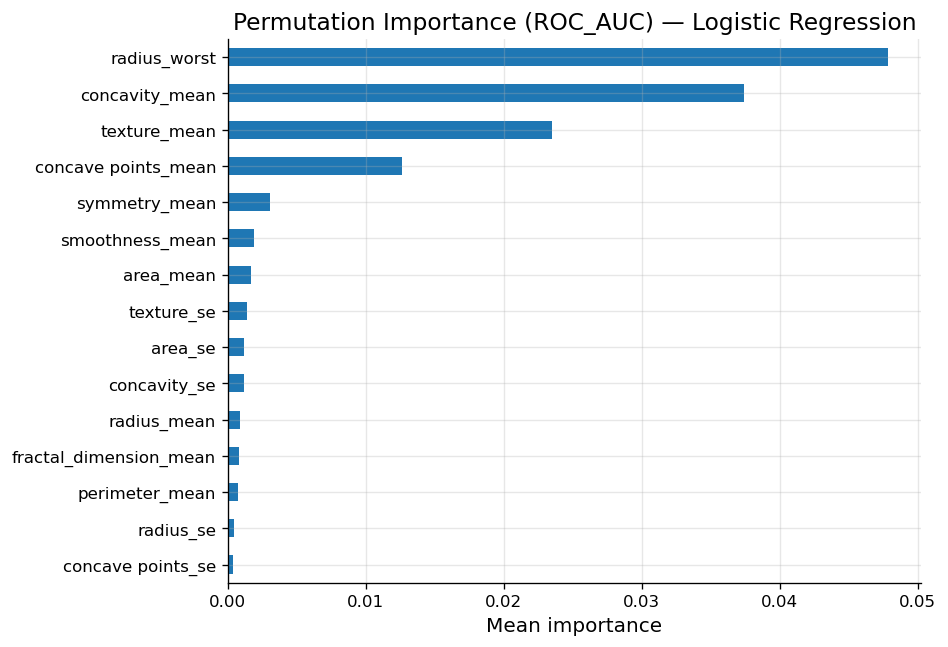

In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="roc_auc"
)

perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False).head(15)
display(perm_imp.to_frame("perm_importance_mean"))

fig, ax = plt.subplots(figsize=(8, 5.5))
perm_imp.sort_values().plot(kind="barh", ax=ax)
ax.set_title(f"Permutation Importance (ROC_AUC) — {best_model_name}")
ax.set_xlabel("Mean importance")
prettify(ax)
fig.tight_layout()
plt.show()

## 4. Unsupervised Learning: KMeans Clustering



### 4.1 Identify optimal number of clusters (Elbow + Silhouette)

We compute:
- **Inertia** (Elbow Method): within-cluster sum of squares.
- **Silhouette score**: how well points fit within their cluster compared to others.

We evaluate k = 2..10 and choose the k with the highest silhouette score as `best_k`.


d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\ANACONDA\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass

,k,inertia,silhouette
0,2,8304.409577,0.351388
1,3,7105.122756,0.311543
2,4,6398.365770,0.282938
3,5,5877.480102,0.204968
4,6,5447.271539,0.189563
5,7,5087.886078,0.194405
6,8,4864.601213,0.167711
7,9,4693.707894,0.137877
8,10,4481.556868,0.145021


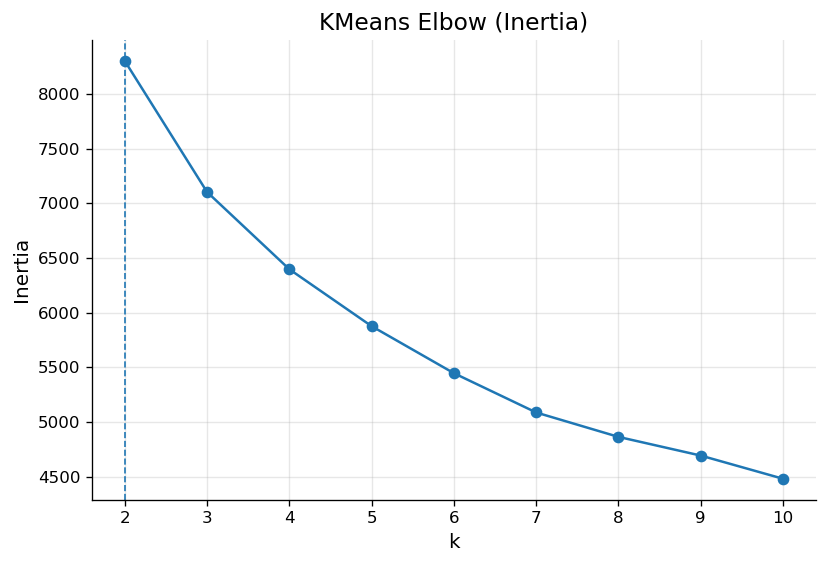

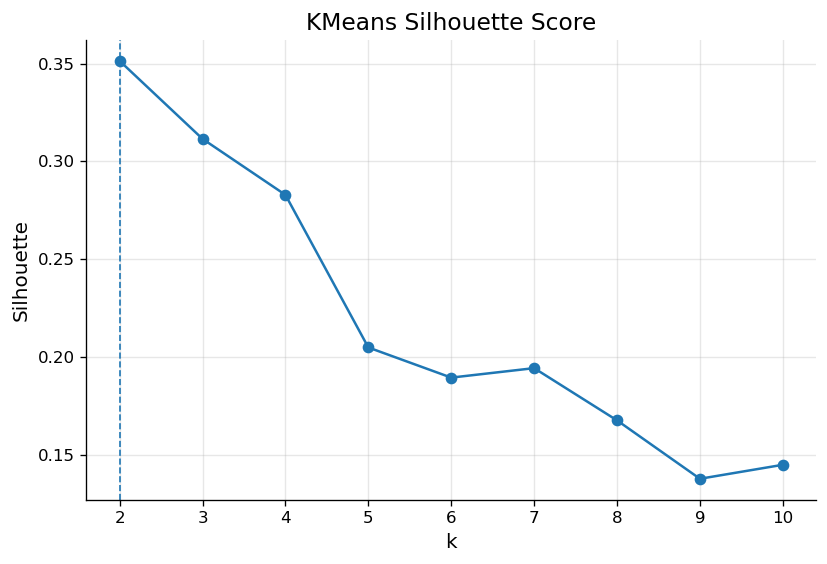

Best k (by silhouette): 2


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Summary table (helps justify k choice)
k_summary = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': sil_scores
})
display(k_summary)


best_k = list(k_values)[int(np.argmax(sil_scores))]

# Elbow plot
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(list(k_values), inertias, marker="o", linewidth=1.5)
ax.set_title("KMeans Elbow (Inertia)")
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.axvline(best_k, linestyle="--", linewidth=1)
prettify(ax)
fig.tight_layout()
plt.show()

# Silhouette plot
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(list(k_values), sil_scores, marker="o", linewidth=1.5)
ax.set_title("KMeans Silhouette Score")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette")
ax.axvline(best_k, linestyle="--", linewidth=1)
prettify(ax)
fig.tight_layout()
plt.show()

print("Best k (by silhouette):", best_k)


### 4.2 Fit final KMeans model and profile clusters

After selecting `best_k`, we fit KMeans and profile each cluster (size, diagnosis mix, and feature averages).


In [22]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["cluster"] = clusters

print("Cluster sizes:")
display(df_clustered["cluster"].value_counts().sort_index())

print("\nCluster vs Diagnosis (proportion):")
ct = pd.crosstab(df_clustered["cluster"], df_clustered["diagnosis"], normalize="index")
display(ct)

print("\nCluster feature means (scaled-space not shown; raw-space means shown):")
cluster_profile = df_clustered.drop(columns=DROP_COLS + [TARGET]).groupby("cluster").mean()
display(cluster_profile)


Cluster sizes:


d:\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


cluster
0    172
1    397
Name: count, dtype: int64


Cluster vs Diagnosis (proportion):


diagnosis,0,1
cluster,,
0,0.081395,0.918605
1,0.863980,0.136020



Cluster feature means (scaled-space not shown; raw-space means shown):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst
cluster,,,,,,,,,,,,,,,,,,,,,
0,17.851593,21.491860,118.459651,1026.273837,0.104934,0.160255,0.184854,0.096965,0.198294,0.064486,...,1.284895,4.825843,81.717721,0.007316,0.039302,0.053233,0.017336,0.022360,0.005075,21.622733
1,12.513741,18.335542,80.491990,493.986902,0.092646,0.080116,0.047184,0.028103,0.173740,0.062066,...,1.187374,2.016984,22.408942,0.006922,0.019489,0.022648,0.009396,0.019755,0.003240,13.949771


### 4.3 PCA visualization (2D)

We project the standardized features into 2D using PCA to visualize cluster separation.


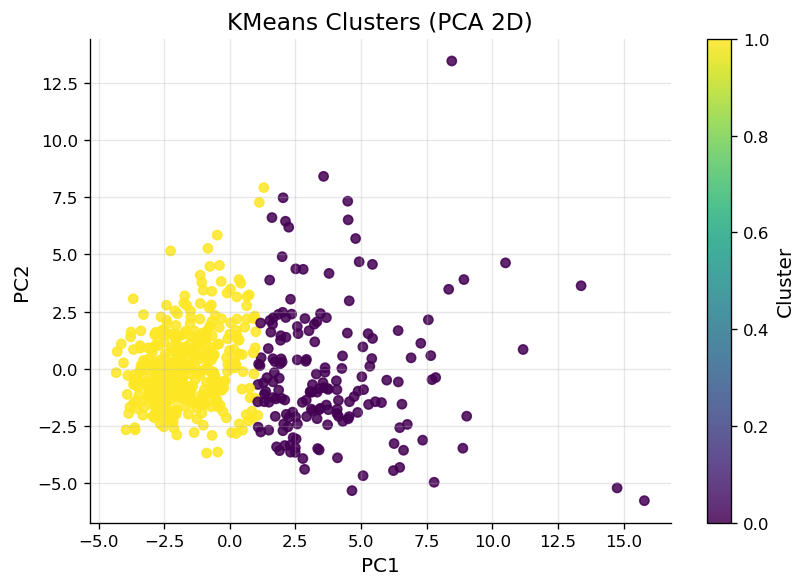

Explained variance ratio (PC1, PC2): [0.44401311 0.21463706]


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.85, s=30)
ax.set_title("KMeans Clusters (PCA 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
prettify(ax)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Cluster")
fig.tight_layout()
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)